# Credit Card Default Prediction with UCI_Credit_Card Dataset

This notebook builds and evaluates a machine learning model to predict credit card default using the UCI_Credit_Card dataset. The provided `train_data` and `test_data` folders are used for training and evaluation.


## 1. Import Required Libraries

Import pandas, numpy, scikit-learn, and any other necessary libraries for data handling, preprocessing, modeling, and evaluation.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Explore Training and Test Data

Load the training and test datasets from the provided folders. Display the first few rows and basic statistics to understand the data.

In [3]:
train_df = pd.read_csv('./data/train_data/train.csv')
test_df = pd.read_csv('./data/test_data/test.csv')
augmented_df = pd.read_csv("./data/train_data/augmented_generated.csv")

display(train_df)
display(augmented_df)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,22789,160000.0,2,2,2,33,2,2,3,2,...,164310.0,162681.0,163005.0,15000.0,0.0,0.0,6100.0,12300.0,6100.0,0
1,29007,150000.0,2,1,2,34,1,-1,-1,-2,...,0.0,0.0,0.0,53.0,0.0,0.0,0.0,0.0,0.0,0
2,16951,10000.0,1,2,1,50,1,2,0,0,...,8067.0,8227.0,8400.0,2.0,1281.0,1134.0,294.0,305.0,1000.0,0
3,22281,220000.0,2,1,2,29,0,0,0,0,...,218513.0,131660.0,134346.0,9100.0,9000.0,7887.0,4800.0,4900.0,6000.0,1
4,11347,310000.0,2,1,2,32,1,-2,-1,0,...,326.0,-235.0,-235.0,0.0,326.0,0.0,0.0,0.0,1200.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,23480,100000.0,2,2,2,31,0,0,0,0,...,97486.0,97604.0,97241.0,3309.0,4421.0,5486.0,3400.0,3541.0,3894.0,1
23996,13922,120000.0,2,2,2,24,0,0,0,0,...,113948.0,122127.0,121962.0,4200.0,4100.0,4100.0,10000.0,4560.0,0.0,0
23997,3795,120000.0,2,1,2,24,0,0,0,0,...,49924.0,33188.0,19826.0,3700.0,2023.0,2016.0,2000.0,1200.0,1000.0,0
23998,27566,360000.0,1,1,1,57,1,-2,-1,-1,...,246.0,-46.0,-46.0,0.0,860.0,246.0,0.0,0.0,0.0,0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,6908,50000.0,1,2,2,46,-1,-1,-1,-1,...,2650.0,3320.0,2764.0,26060.0,0.0,3472.0,2320.0,1764.0,2841.0,0
1,26934,150000.0,1,2,1,38,0,0,0,0,...,98765.0,87654.0,76543.0,6000.0,5000.0,4000.0,3500.0,3000.0,2500.0,0
2,24098,110000.0,2,3,2,29,1,-1,-1,0,...,87654.0,76543.0,65432.0,5000.0,4000.0,3500.0,3000.0,2500.0,2000.0,1
3,20987,200000.0,1,1,1,42,2,2,2,2,...,156789.0,143210.0,129876.0,10000.0,9000.0,8000.0,7000.0,6000.0,5000.0,0
4,23976,220000.0,2,2,2,27,0,0,0,0,...,176543.0,156789.0,143210.0,12000.0,11000.0,10000.0,9000.0,8000.0,7000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,10089,70000.0,1,3,1,47,0,0,2,2,...,63000.0,61000.0,59000.0,57000.0,55000.0,53000.0,51000.0,49000.0,47000.0,1
123,6627,440000.0,2,2,2,40,0,0,0,0,...,410000.0,400000.0,390000.0,380000.0,370000.0,360000.0,350000.0,340000.0,330000.0,0
124,26007,300000.0,2,2,2,30,0,0,0,-2,...,270000.0,260000.0,250000.0,240000.0,230000.0,220000.0,210000.0,200000.0,190000.0,1
125,20519,40000.0,1,1,2,27,2,0,0,0,...,34000.0,32000.0,30000.0,28000.0,26000.0,24000.0,22000.0,20000.0,18000.0,1


## 3. Preprocess Data (Handle Missing Values, Encode Categoricals, Feature Scaling)

Check for and handle missing values, encode categorical variables if necessary, and apply feature scaling to numerical features.

In [4]:
# Handle missing values
train_df = train_df.dropna()
test_df = test_df.dropna()

# Encode categorical variables if needed (assuming all are numeric except 'SEX', 'EDUCATION', 'MARRIAGE')
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in categorical_cols:
    if col in train_df.columns:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col])
        if col in test_df.columns:
            test_df[col] = le.transform(test_df[col])

# Feature scaling (excluding target and ID)
feature_cols = [col for col in train_df.columns if col not in ['ID', 'default.payment.next.month']]
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
if not test_df.empty:
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])

## 4. Split Training Data into Features and Target

Separate the features (X) and the target variable (y = 'default.payment.next.month') from the training data.

In [5]:
# Split features and target
X = train_df.drop(['ID', 'default.payment.next.month'], axis=1)
y = train_df['default.payment.next.month']

print(X.shape)
print(y.shape)

(24000, 23)
(24000,)


## 5. Train a Classification Model

Train a classification model (Random Forest) using the preprocessed training data.

,model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.811833,0.796766,0.811833,0.774152
1,RandomForest,0.999458,0.999458,0.999458,0.999458
2,DecisionTree,0.825208,0.810131,0.825208,0.804215


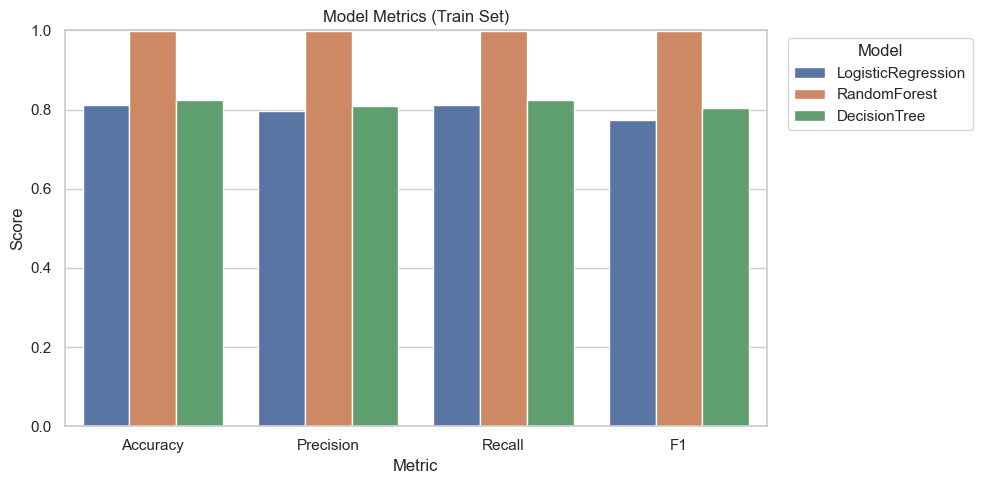

In [13]:
# --- Train 3 models (assumes X, y already prepared/preprocessed) ---
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
}

for name, model in models.items():
    model.fit(X, y)

# --- Predict + compute metrics on the same dataset (X, y) ---
rows = []
preds_train = {}

for name, model in models.items():
    y_pred = model.predict(X)
    preds_train[name] = y_pred

    rows.append(
        {
            "model": name,
            "Accuracy": accuracy_score(y, y_pred),
            "Precision": precision_score(y, y_pred, average="weighted", zero_division=0),
            "Recall": recall_score(y, y_pred, average="weighted", zero_division=0),
            "F1": f1_score(y, y_pred, average="weighted", zero_division=0),
        }
    )

metrics_df = pd.DataFrame(rows)
metrics_long = metrics_df.melt(id_vars="model", var_name="metric", value_name="value")

display(metrics_df)

# --- Grouped bar chart: metric category on x-axis, model as hue ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=metrics_long, x="metric", y="value", hue="model")
ax.set_title("Model Metrics (Train Set)")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Train Second Model with Augmented (Synthetic) Data

Now, we will train a second model using the original training data combined with synthetic data. We will then predict on the same test set and compare both models' performance.

In [7]:
import pandas as pd

# Load original training data
train_df = pd.read_csv('./data/train_data/train.csv')
test_df = pd.read_csv('./data/test_data/test.csv')
# Load synthetic/augmented data (replace with your actual file or DataFrame)
augmented_df = pd.read_csv('./data/train_data/augmented_generated.csv')  # or your generated CSV filename

# Concatenate the two DataFrames
augmented_train_df = pd.concat([train_df, augmented_df], ignore_index=True)

print('Combined training data shape:', augmented_train_df.shape)
display(augmented_train_df.head())

# Split features and target for augmented data
X_aug = augmented_train_df.drop(['ID', 'default.payment.next.month'], axis=1)
y_aug = augmented_train_df['default.payment.next.month']

X_test = test_df.drop(['ID', 'default.payment.next.month'], axis=1)
y_test = test_df['default.payment.next.month']

Combined training data shape: (24127, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,22789,160000.0,2,2,2,33,2,2,3,2,...,164310.0,162681.0,163005.0,15000.0,0.0,0.0,6100.0,12300.0,6100.0,0
1,29007,150000.0,2,1,2,34,1,-1,-1,-2,...,0.0,0.0,0.0,53.0,0.0,0.0,0.0,0.0,0.0,0
2,16951,10000.0,1,2,1,50,1,2,0,0,...,8067.0,8227.0,8400.0,2.0,1281.0,1134.0,294.0,305.0,1000.0,0
3,22281,220000.0,2,1,2,29,0,0,0,0,...,218513.0,131660.0,134346.0,9100.0,9000.0,7887.0,4800.0,4900.0,6000.0,1
4,11347,310000.0,2,1,2,32,1,-2,-1,0,...,326.0,-235.0,-235.0,0.0,326.0,0.0,0.0,0.0,1200.0,0


e:\Projects\genai1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


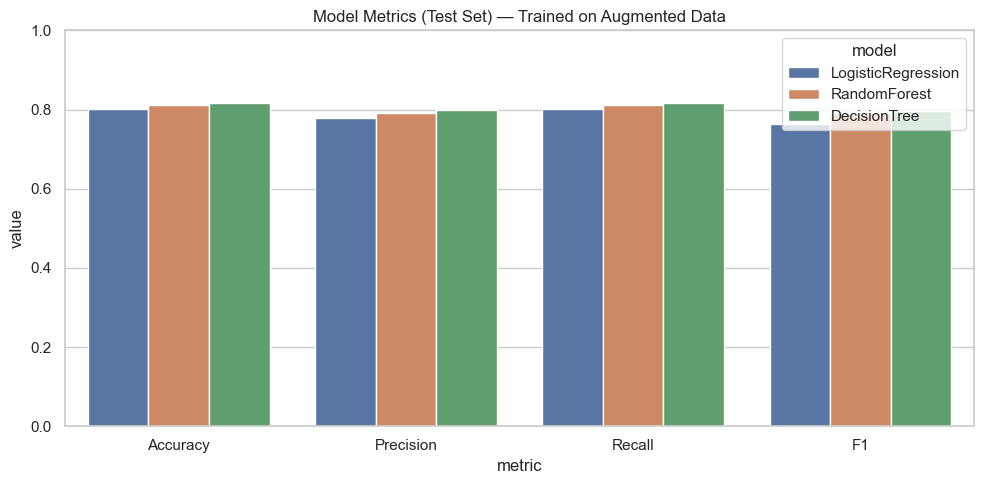

In [8]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
}

# Fit on augmented training set
for name, model in models.items():
    model.fit(X_aug, y_aug)

# Make sure test features match training features exactly
X_test_aligned = X_test.reindex(columns=X_aug.columns)

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test_aligned)
    rows.append({
        "model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

metrics_df = pd.DataFrame(rows)
metrics_long = metrics_df.melt(id_vars="model", var_name="metric", value_name="value")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=metrics_long, x="metric", y="value", hue="model")
ax.set_title("Model Metrics (Test Set) — Trained on Augmented Data")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# 10. Truncating training set to amplify the effect of augmented data

In [9]:
# Sampling original training dataset to 20% original size
# Add augmented dataset on top

TARGET_COL = "default.payment.next.month"

# sample 20% of the original training set
# stratified sampling to keep the class balance similar
train_sample_20, _ = train_test_split(
	train_df,
	train_size=0.20,
	random_state=42,
	stratify=train_df[TARGET_COL],
)
# concatenate sampled-original + augmented, then shuffle
augmented_train_df = pd.concat([train_sample_20, augmented_df], ignore_index=True)
augmented_train_df = augmented_train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Original train shape:", train_df.shape)
print("20% sample shape:", train_sample_20.shape)
print("Augmented shape:", augmented_df.shape)
print("Combined (20% + augmented) shape:", augmented_train_df.shape)

display(augmented_train_df.head())
display(augmented_train_df.columns)

Original train shape: (24000, 25)
20% sample shape: (4800, 25)
Augmented shape: (127, 25)
Combined (20% + augmented) shape: (4927, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1123,50000.0,1,2,2,26,0,0,0,0,...,49668.0,49780.0,49980.0,2571.0,1200.0,1000.0,40000.0,1000.0,0.0,0
1,14276,500000.0,2,2,1,42,0,0,0,0,...,76519.0,77223.0,76684.0,17624.0,14783.0,3000.0,3000.0,2853.0,2385.0,0
2,22719,230000.0,2,2,1,45,-1,-1,-1,-1,...,31886.0,14893.0,8343.0,17094.0,8786.0,32467.0,14893.0,0.0,8968.0,0
3,25708,500000.0,2,1,2,30,-1,-1,-1,-1,...,9274.0,10642.0,11986.0,11075.0,4405.0,9274.0,4000.0,5000.0,53918.0,0
4,23976,20000.0,1,1,2,25,0,0,0,0,...,8798.0,9404.0,6864.0,1200.0,2000.0,2000.0,1000.0,1000.0,1000.0,0


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

ID_COL = "ID"
TARGET_COL = "default.payment.next.month"
categorical_cols = [c for c in ["SEX", "EDUCATION", "MARRIAGE"] if c in augmented_train_df.columns]

# Clean copies
augmented_train_df = augmented_train_df.dropna().copy()
test_df = test_df.dropna().copy()

# Split train X/y
y_aug = augmented_train_df[TARGET_COL]
X_aug_df = augmented_train_df.drop(columns=[ID_COL, TARGET_COL])

# Split test X/y
y_test = test_df[TARGET_COL] if TARGET_COL in test_df.columns else None
X_test_df = test_df.drop(columns=[c for c in [ID_COL, TARGET_COL] if c in test_df.columns])

# Align test columns to train columns (names + order)
X_test_df = X_test_df.reindex(columns=X_aug_df.columns)

# --- LabelEncode each categorical column separately (safe for unseen categories) ---
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on TRAIN only
    X_aug_df[col] = le.fit_transform(X_aug_df[col].astype(str))
    label_encoders[col] = le

    # Safe transform for TEST: map unknowns to -1 instead of crashing
    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_test_df[col] = X_test_df[col].astype(str).map(mapping).dropna().astype(int)

# --- Scale numeric columns (fit on train, transform test) ---
numeric_cols = [c for c in X_aug_df.columns if c not in categorical_cols]

scaler = StandardScaler()
X_aug_df[numeric_cols] = scaler.fit_transform(X_aug_df[numeric_cols])
X_test_df[numeric_cols] = scaler.transform(X_test_df[numeric_cols])

# Final matrices
X_aug = X_aug_df
X_test = X_test_df

print("Encoded categoricals:", categorical_cols)
print("X_aug:", X_aug.shape, "y_aug:", y_aug.shape)
print("X_test:", X_test.shape, "y_test:", None if y_test is None else y_test.shape)

Encoded categoricals: ['SEX', 'EDUCATION', 'MARRIAGE']
X_aug: (4927, 23) y_aug: (4927,)
X_test: (6000, 23) y_test: (6000,)


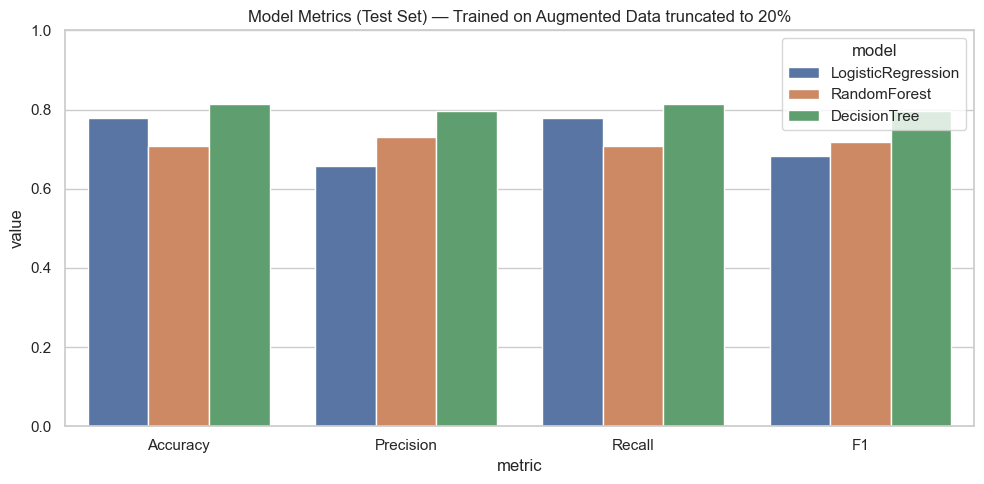

In [12]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
}

# Fit on augmented training set
for name, model in models.items():
    model.fit(X_aug, y_aug)

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test_aligned)
    rows.append({
        "model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

metrics_df = pd.DataFrame(rows)
metrics_long = metrics_df.melt(id_vars="model", var_name="metric", value_name="value")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=metrics_long, x="metric", y="value", hue="model")
ax.set_title("Model Metrics (Test Set) — Trained on Augmented Data truncated to 20%")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()